# Test new parking-frequency algorithm on May 8 ODMR sweeps

This notebook tests the newer parking-frequency workflow from Michael's `NV_Magnetometry_Software` on the local `odmr_sweep_20260508_*.csv` data.

The key difference from the older lock-in planning helper is that this notebook explicitly runs:

1. baseline-corrected dip candidate detection,
2. candidate clustering and center collapse,
3. local dip fitting,
4. physical paired-peak rejection via `reject_unpaired_peaks`, and
5. DB/IB parking frequencies at `center +/- FWHM/2` for each kept transition.

It does not talk to the RFSoC. It only reads ODMR CSVs and writes diagnostic CSV/PNG outputs.

In [1]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


def render(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


def find_workspace_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "nv_magnetometer_project").is_dir() and (candidate / "NV_Magnetometry_Software-main").is_dir():
            return candidate
    raise FileNotFoundError("Could not find workspace root containing nv_magnetometer_project and NV_Magnetometry_Software-main")


WORKSPACE_ROOT = find_workspace_root()
PROJECT_ROOT = WORKSPACE_ROOT / "nv_magnetometer_project"
NV_REPO_DIR = WORKSPACE_ROOT / "NV_Magnetometry_Software-main"
ODMR_DIR = PROJECT_ROOT / "data" / "odmr_sweeps"
OUT_DIR = PROJECT_ROOT / "data" / "lockin_multipoint" / "parking_algorithm_tests"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(NV_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(NV_REPO_DIR))

from nv_toolkit.peaks import (  # noqa: E402
    detect_baseline_corrected_dip_candidates,
    cluster_dip_candidates,
    collapse_candidate_clusters,
    fit_local_dips,
    reject_unpaired_peaks,
)
from nv_toolkit.tui import _load_operator_full_scan  # noqa: E402

print(f"Workspace: {WORKSPACE_ROOT}")
print(f"ODMR dir:  {ODMR_DIR}")
print(f"Outputs:   {OUT_DIR}")
print(f"nv_toolkit: {NV_REPO_DIR}")

Matplotlib is building the font cache; this may take a moment.


Workspace: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer
ODMR dir:  /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps
Outputs:   /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests
nv_toolkit: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/NV_Magnetometry_Software-main


## Configuration

By default this scans every `odmr_sweep_20260508_*.csv`. Set `FOCUS_FILES` to a list of filenames if you only want a few sweeps.

In [2]:
ODMR_DATE = "20260508"
FOCUS_FILES: list[str] = []

# Use None for all matching sweeps. Use a small integer for the most recent N sweeps.
MAX_SWEEPS: int | None = None

# New parking algorithm parameters, matching the upstream phase1 workflow for broad full sweeps.
SNR_THRESHOLD = 1.5
CLUSTER_MERGE_MHZ = 3.0
FIT_WINDOW_MHZ = 8.0
MAX_CENTERS = 8

FWHM_FLOOR_MHZ = 0.200
FWHM_FALLBACK_MHZ = 0.5

# Plot only the last N sweeps to keep notebook output readable.
PLOT_LAST_N = 6

In [3]:
def safe_fwhm(fwhm_mhz: float) -> float:
    fwhm = float(fwhm_mhz)
    return fwhm if fwhm > FWHM_FLOOR_MHZ + 0.01 else FWHM_FALLBACK_MHZ


def load_odmr_csv(path: Path) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    df = pd.read_csv(path)
    required = {"frequency_MHz", "photoluminescence_mw_on_ADC"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path.name} missing required columns: {sorted(missing)}")
    freqs = df["frequency_MHz"].to_numpy(dtype=float)
    mw_on = df["photoluminescence_mw_on_ADC"].to_numpy(dtype=float)
    pl = mw_on / float(np.median(mw_on))
    return freqs, pl, df


def compute_parking_for_odmr(
    path: Path,
    *,
    snr_threshold: float = SNR_THRESHOLD,
    cluster_merge_mhz: float = CLUSTER_MERGE_MHZ,
    fit_window_mhz: float = FIT_WINDOW_MHZ,
    max_centers: int = MAX_CENTERS,
) -> dict[str, object]:
    freqs, pl, raw_df = load_odmr_csv(path)
    sweep_range = (float(np.nanmin(freqs)), float(np.nanmax(freqs)))

    candidates = detect_baseline_corrected_dip_candidates(
        freqs,
        pl,
        min_prominence_sigma=snr_threshold,
    )
    clusters = cluster_dip_candidates(candidates, merge_distance_mhz=cluster_merge_mhz)
    centers, cluster_rows = collapse_candidate_clusters(clusters, max_centers=max_centers)

    fits = fit_local_dips(
        freqs,
        pl,
        centers,
        window_mhz=fit_window_mhz,
        hyperfine_merge_mhz=0.0,
    )
    kept, rejected = reject_unpaired_peaks(fits, sweep_range)
    kept = sorted(kept, key=lambda f: f.center_mhz)
    rejected = sorted(rejected, key=lambda f: f.center_mhz)

    parking_rows = []
    for group_index, fit in enumerate(kept, start=1):
        fwhm = safe_fwhm(fit.linewidth_mhz)
        parking_rows.append({
            "odmr_file": path.name,
            "nv_group": group_index,
            "boundary": "DB",
            "ref_peak_center_mhz": float(fit.center_mhz),
            "fwhm_mhz": fwhm,
            "parking_freq_mhz": float(fit.center_mhz - fwhm / 2.0),
            "fit_success": bool(fit.success),
            "fit_cost": float(fit.cost),
            "contrast": float(fit.contrast),
        })
        parking_rows.append({
            "odmr_file": path.name,
            "nv_group": group_index,
            "boundary": "IB",
            "ref_peak_center_mhz": float(fit.center_mhz),
            "fwhm_mhz": fwhm,
            "parking_freq_mhz": float(fit.center_mhz + fwhm / 2.0),
            "fit_success": bool(fit.success),
            "fit_cost": float(fit.cost),
            "contrast": float(fit.contrast),
        })

    parking_df = pd.DataFrame(parking_rows)
    return {
        "path": path,
        "freqs": freqs,
        "pl": pl,
        "raw_df": raw_df,
        "candidates": candidates,
        "clusters": clusters,
        "cluster_rows": cluster_rows,
        "centers": np.asarray(centers, dtype=float),
        "fits": fits,
        "kept": kept,
        "rejected": rejected,
        "parking_df": parking_df,
    }


def old_tui_centers(path: Path) -> np.ndarray:
    _freqs, _measured, centers = _load_operator_full_scan(path, "auto")
    return np.asarray(centers, dtype=float)


def summarize_result(result: dict[str, object]) -> dict[str, object]:
    path = result["path"]
    candidates = result["candidates"]
    centers = result["centers"]
    kept = result["kept"]
    rejected = result["rejected"]
    parking_df = result["parking_df"]
    return {
        "odmr_file": Path(path).name,
        "n_candidates": len(candidates),
        "n_collapsed_centers": len(centers),
        "n_kept": len(kept),
        "n_rejected": len(rejected),
        "n_parking_freqs": len(parking_df),
        "kept_centers_mhz": ", ".join(f"{fit.center_mhz:.3f}" for fit in kept),
        "rejected_centers_mhz": ", ".join(f"{fit.center_mhz:.3f}" for fit in rejected),
    }


def plot_parking_result(result: dict[str, object], *, save: bool = True) -> Path | None:
    path = result["path"]
    freqs = result["freqs"]
    pl = result["pl"]
    parking_df = result["parking_df"]
    kept = result["kept"]
    rejected = result["rejected"]

    fig, ax = plt.subplots(figsize=(13, 4.8))
    ax.plot(freqs, pl, color="steelblue", lw=1.0, label="normalized MW-on")

    if len(parking_df):
        groups = sorted(parking_df["nv_group"].unique())
        colors = plt.cm.tab10(np.linspace(0, 1, max(len(groups), 1)))
        for color, group in zip(colors, groups):
            sub = parking_df[parking_df["nv_group"] == group]
            db = float(sub.loc[sub["boundary"] == "DB", "parking_freq_mhz"].iloc[0])
            ib = float(sub.loc[sub["boundary"] == "IB", "parking_freq_mhz"].iloc[0])
            center = float(sub["ref_peak_center_mhz"].iloc[0])
            ax.axvline(db, color=color, ls="--", lw=1.2, alpha=0.9)
            ax.axvline(ib, color=color, ls="-.", lw=1.2, alpha=0.9)
            ax.axvline(center, color=color, ls=":", lw=0.8, alpha=0.7)
            ax.axvspan(db, ib, color=color, alpha=0.06)
            ax.text(center, np.nanmin(pl), f"G{group}", ha="center", va="bottom", fontsize=8, color=color)

    for fit in rejected:
        ax.axvline(fit.center_mhz, color="crimson", lw=1.6, alpha=0.8, label="rejected" if fit is rejected[0] else None)

    ax.set_title(f"New parking algorithm: {Path(path).name} | kept {len(kept)}, rejected {len(rejected)}")
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("MW-on / median")
    ax.legend(loc="best")
    fig.tight_layout()

    out_path = None
    if save:
        out_path = OUT_DIR / f"{Path(path).stem}_new_parking_algorithm.png"
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
    render(fig)
    return out_path

## Discover May 8 ODMR sweeps

In [4]:
all_odmr_files = sorted(ODMR_DIR.glob(f"odmr_sweep_{ODMR_DATE}_*.csv"))
if FOCUS_FILES:
    selected_files = []
    for item in FOCUS_FILES:
        p = Path(item)
        if not p.is_absolute():
            p = ODMR_DIR / item
        selected_files.append(p)
else:
    selected_files = all_odmr_files[-MAX_SWEEPS:] if MAX_SWEEPS is not None else all_odmr_files

if not selected_files:
    raise FileNotFoundError(f"No ODMR files matched odmr_sweep_{ODMR_DATE}_*.csv in {ODMR_DIR}")

print(f"Found {len(all_odmr_files)} ODMR sweeps for {ODMR_DATE}.")
print(f"Selected {len(selected_files)} sweeps for fitting.")
for path in selected_files:
    print(" -", path.name)

Found 15 ODMR sweeps for 20260508.
Selected 15 sweeps for fitting.
 - odmr_sweep_20260508_082449.csv
 - odmr_sweep_20260508_095444.csv
 - odmr_sweep_20260508_100150.csv
 - odmr_sweep_20260508_140708.csv
 - odmr_sweep_20260508_141646.csv
 - odmr_sweep_20260508_142409.csv
 - odmr_sweep_20260508_142548.csv
 - odmr_sweep_20260508_143240.csv
 - odmr_sweep_20260508_143713.csv
 - odmr_sweep_20260508_143836.csv
 - odmr_sweep_20260508_144028.csv
 - odmr_sweep_20260508_144228.csv
 - odmr_sweep_20260508_144843.csv
 - odmr_sweep_20260508_145956.csv
 - odmr_sweep_20260508_151705.csv


## Run the new parking-frequency workflow

In [5]:
results = []
errors = []
for path in selected_files:
    try:
        result = compute_parking_for_odmr(path)
        results.append(result)
    except Exception as exc:
        errors.append({"odmr_file": path.name, "error_type": type(exc).__name__, "error": str(exc)})

summary_df = pd.DataFrame([summarize_result(result) for result in results])
error_df = pd.DataFrame(errors)

summary_csv = OUT_DIR / f"parking_algorithm_summary_{ODMR_DATE}.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Saved summary: {summary_csv}")
display(summary_df)

if len(error_df):
    error_csv = OUT_DIR / f"parking_algorithm_errors_{ODMR_DATE}.csv"
    error_df.to_csv(error_csv, index=False)
    print(f"Saved errors: {error_csv}")
    display(error_df)

Saved summary: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests/parking_algorithm_summary_20260508.csv


,odmr_file,n_candidates,n_collapsed_centers,n_kept,n_rejected,n_parking_freqs,kept_centers_mhz,rejected_centers_mhz
0,odmr_sweep_20260508_082449.csv,8,8,8,0,16,"2767.001, 2805.381, 2838.798, 2872.189, 2880.1...",
1,odmr_sweep_20260508_095444.csv,8,8,8,0,16,"2767.085, 2805.609, 2838.783, 2872.365, 2880.3...",
2,odmr_sweep_20260508_100150.csv,8,8,8,0,16,"2767.467, 2806.321, 2840.206, 2872.532, 2880.5...",
3,odmr_sweep_20260508_140708.csv,8,8,8,0,16,"2769.029, 2806.552, 2841.682, 2872.496, 2880.4...",
4,odmr_sweep_20260508_141646.csv,8,8,8,0,16,"2768.924, 2806.658, 2841.490, 2872.400, 2880.5...",
5,odmr_sweep_20260508_142409.csv,8,8,8,0,16,"2768.855, 2806.697, 2841.674, 2872.475, 2880.4...",
6,odmr_sweep_20260508_142548.csv,8,8,8,0,16,"2768.869, 2806.661, 2841.377, 2872.488, 2880.4...",
7,odmr_sweep_20260508_143240.csv,8,8,8,0,16,"2769.031, 2806.375, 2841.784, 2872.369, 2880.3...",
8,odmr_sweep_20260508_143713.csv,8,8,8,0,16,"2768.849, 2806.762, 2841.248, 2872.417, 2880.4...",
9,odmr_sweep_20260508_143836.csv,8,8,8,0,16,"2768.971, 2806.422, 2841.800, 2872.370, 2880.4...",


## Compare old notebook/TUI center detection vs new kept centers

This is useful when the old planning path selects a spurious outer peak.

In [6]:
comparison_rows = []
for result in results:
    path = result["path"]
    try:
        old_centers = old_tui_centers(path)
        old_error = ""
    except Exception as exc:
        old_centers = np.asarray([], dtype=float)
        old_error = f"{type(exc).__name__}: {exc}"
    kept = result["kept"]
    rejected = result["rejected"]
    comparison_rows.append({
        "odmr_file": Path(path).name,
        "old_tui_centers_mhz": ", ".join(f"{x:.3f}" for x in old_centers),
        "new_kept_centers_mhz": ", ".join(f"{fit.center_mhz:.3f}" for fit in kept),
        "new_rejected_centers_mhz": ", ".join(f"{fit.center_mhz:.3f}" for fit in rejected),
        "old_error": old_error,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_csv = OUT_DIR / f"parking_algorithm_old_vs_new_{ODMR_DATE}.csv"
comparison_df.to_csv(comparison_csv, index=False)
print(f"Saved comparison: {comparison_csv}")
display(comparison_df)

Saved comparison: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests/parking_algorithm_old_vs_new_20260508.csv


,odmr_file,old_tui_centers_mhz,new_kept_centers_mhz,new_rejected_centers_mhz,old_error
0,odmr_sweep_20260508_082449.csv,"2629.851, 2766.966, 2805.396, 2838.250, 2872.1...","2767.001, 2805.381, 2838.798, 2872.189, 2880.1...",,
1,odmr_sweep_20260508_095444.csv,"2629.818, 2767.054, 2805.654, 2839.153, 2872.2...","2767.085, 2805.609, 2838.783, 2872.365, 2880.3...",,
2,odmr_sweep_20260508_100150.csv,"2630.286, 2767.356, 2806.549, 2839.687, 2872.5...","2767.467, 2806.321, 2840.206, 2872.532, 2880.5...",,
3,odmr_sweep_20260508_140708.csv,"2630.106, 2768.877, 2806.627, 2840.739, 2872.3...","2769.029, 2806.552, 2841.682, 2872.496, 2880.4...",,
4,odmr_sweep_20260508_141646.csv,"2629.971, 2768.614, 2806.813, 2841.008, 2872.3...","2768.924, 2806.658, 2841.490, 2872.400, 2880.5...",,
5,odmr_sweep_20260508_142409.csv,"2630.000, 2768.709, 2806.889, 2840.776, 2872.3...","2768.855, 2806.697, 2841.674, 2872.475, 2880.4...",,
6,odmr_sweep_20260508_142548.csv,"2630.075, 2768.674, 2806.646, 2840.802, 2872.3...","2768.869, 2806.661, 2841.377, 2872.488, 2880.4...",,
7,odmr_sweep_20260508_143240.csv,"2630.021, 2768.783, 2806.350, 2840.926, 2872.2...","2769.031, 2806.375, 2841.784, 2872.369, 2880.3...",,
8,odmr_sweep_20260508_143713.csv,"2630.012, 2768.656, 2806.880, 2840.530, 2872.3...","2768.849, 2806.762, 2841.248, 2872.417, 2880.4...",,
9,odmr_sweep_20260508_143836.csv,"2629.975, 2768.881, 2806.304, 2841.410, 2872.2...","2768.971, 2806.422, 2841.800, 2872.370, 2880.4...",,


## Combined parking-frequency table

In [7]:
parking_tables = [result["parking_df"] for result in results if len(result["parking_df"])]
all_parking_df = pd.concat(parking_tables, ignore_index=True) if parking_tables else pd.DataFrame()
parking_csv = OUT_DIR / f"parking_algorithm_frequencies_{ODMR_DATE}.csv"
all_parking_df.to_csv(parking_csv, index=False)
print(f"Saved parking frequencies: {parking_csv}")
display(all_parking_df.round({
    "ref_peak_center_mhz": 3,
    "fwhm_mhz": 3,
    "parking_freq_mhz": 3,
    "fit_cost": 6,
    "contrast": 6,
}))

Saved parking frequencies: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests/parking_algorithm_frequencies_20260508.csv


,odmr_file,nv_group,boundary,ref_peak_center_mhz,fwhm_mhz,parking_freq_mhz,fit_success,fit_cost,contrast
0,odmr_sweep_20260508_082449.csv,1,DB,2767.001,9.394,2762.303,True,0.000002,0.013725
1,odmr_sweep_20260508_082449.csv,1,IB,2767.001,9.394,2771.698,True,0.000002,0.013725
2,odmr_sweep_20260508_082449.csv,2,DB,2805.381,9.910,2800.426,True,0.000002,0.006703
3,odmr_sweep_20260508_082449.csv,2,IB,2805.381,9.910,2810.336,True,0.000002,0.006703
4,odmr_sweep_20260508_082449.csv,3,DB,2838.798,11.023,2833.287,True,0.000001,0.004735
...,...,...,...,...,...,...,...,...,...
235,odmr_sweep_20260508_151705.csv,6,IB,2911.780,17.080,2920.320,True,0.000001,0.007413
236,odmr_sweep_20260508_151705.csv,7,DB,2943.916,11.365,2938.233,True,0.000001,0.008344
237,odmr_sweep_20260508_151705.csv,7,IB,2943.916,11.365,2949.598,True,0.000001,0.008344
238,odmr_sweep_20260508_151705.csv,8,DB,2975.132,9.862,2970.200,True,0.000003,0.015348


## Plot the recent fitted sweeps

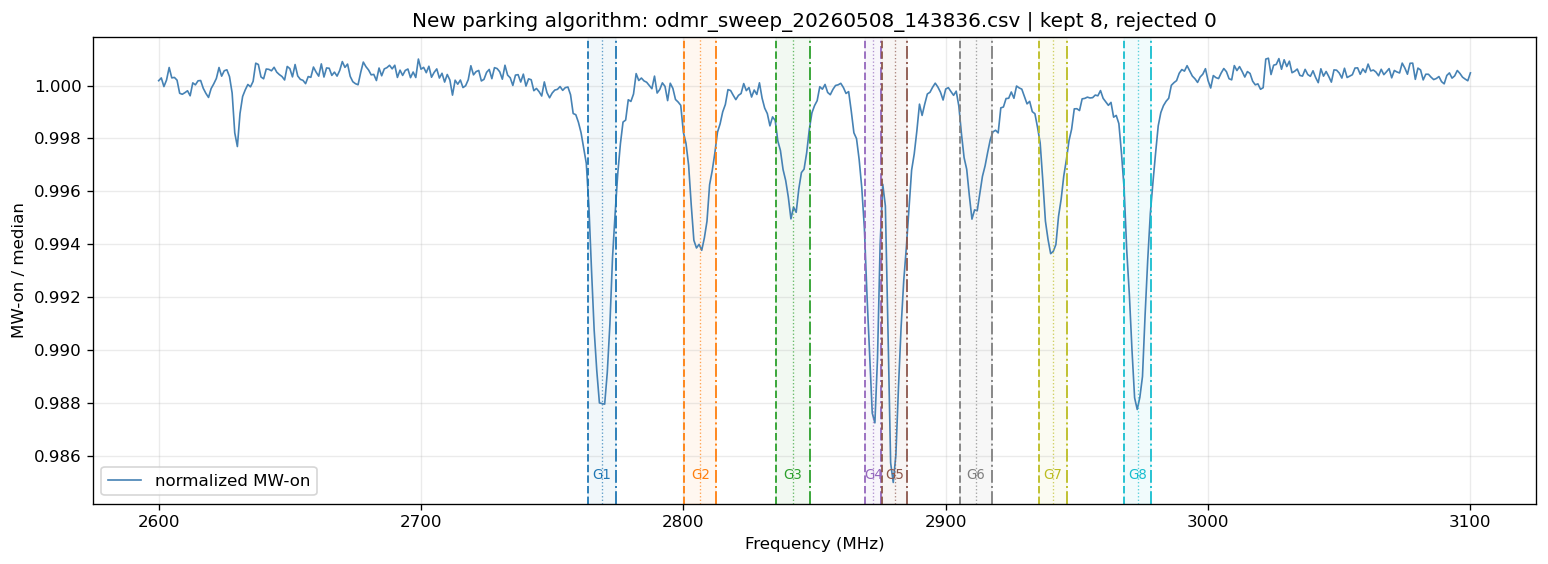

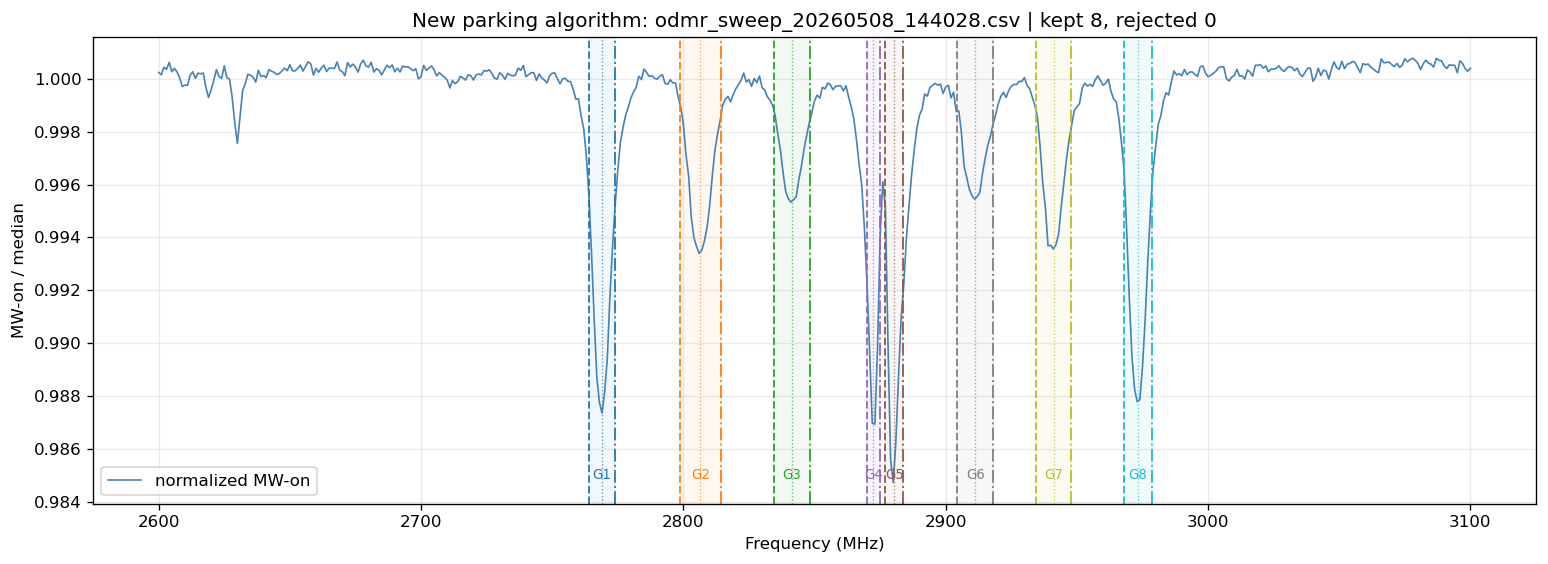

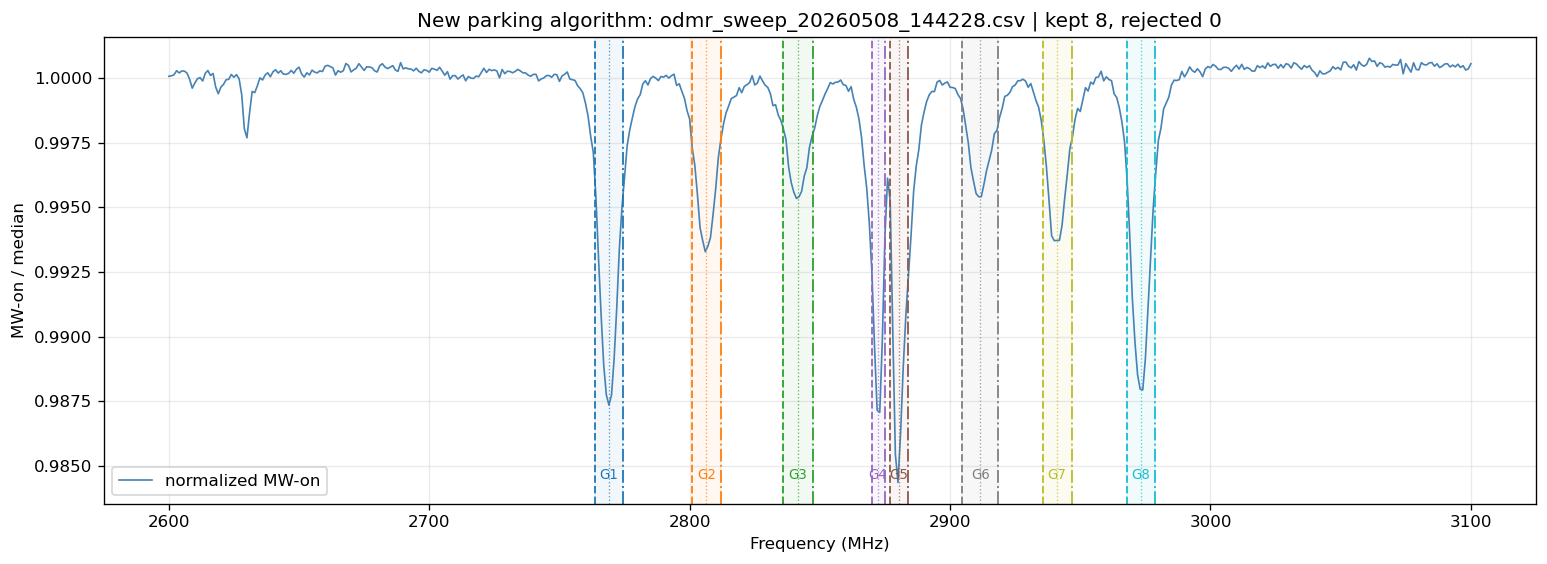

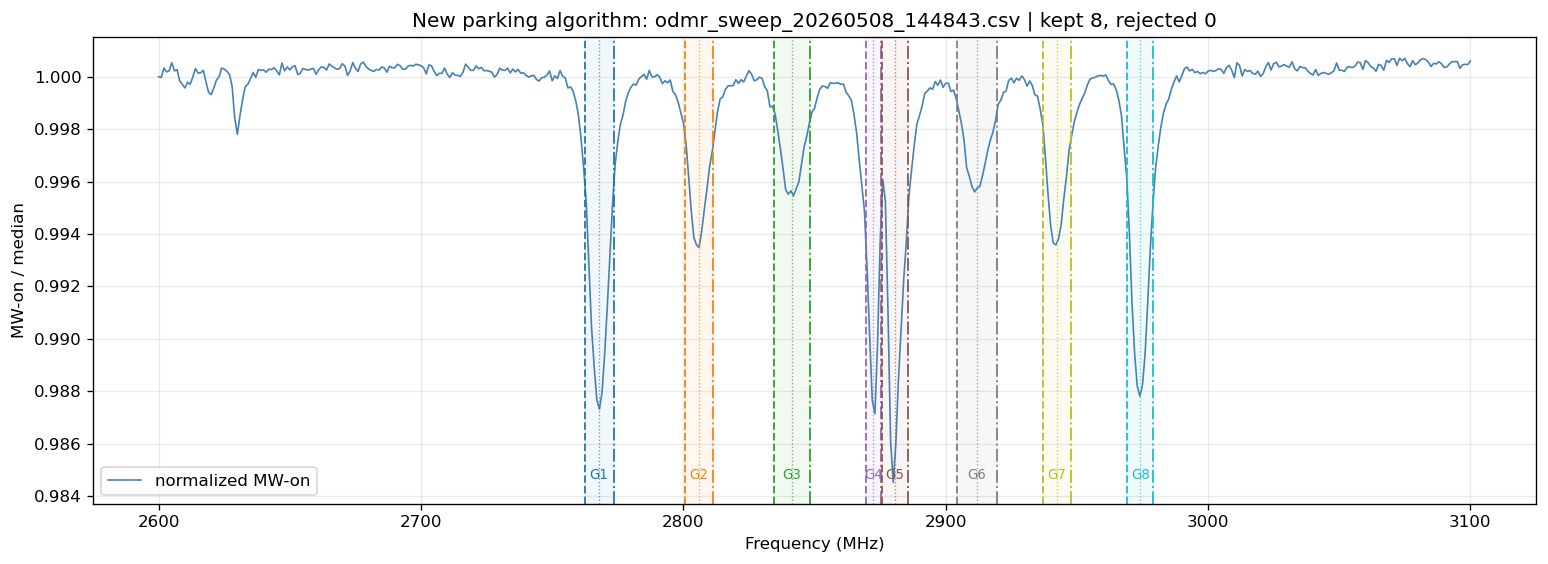

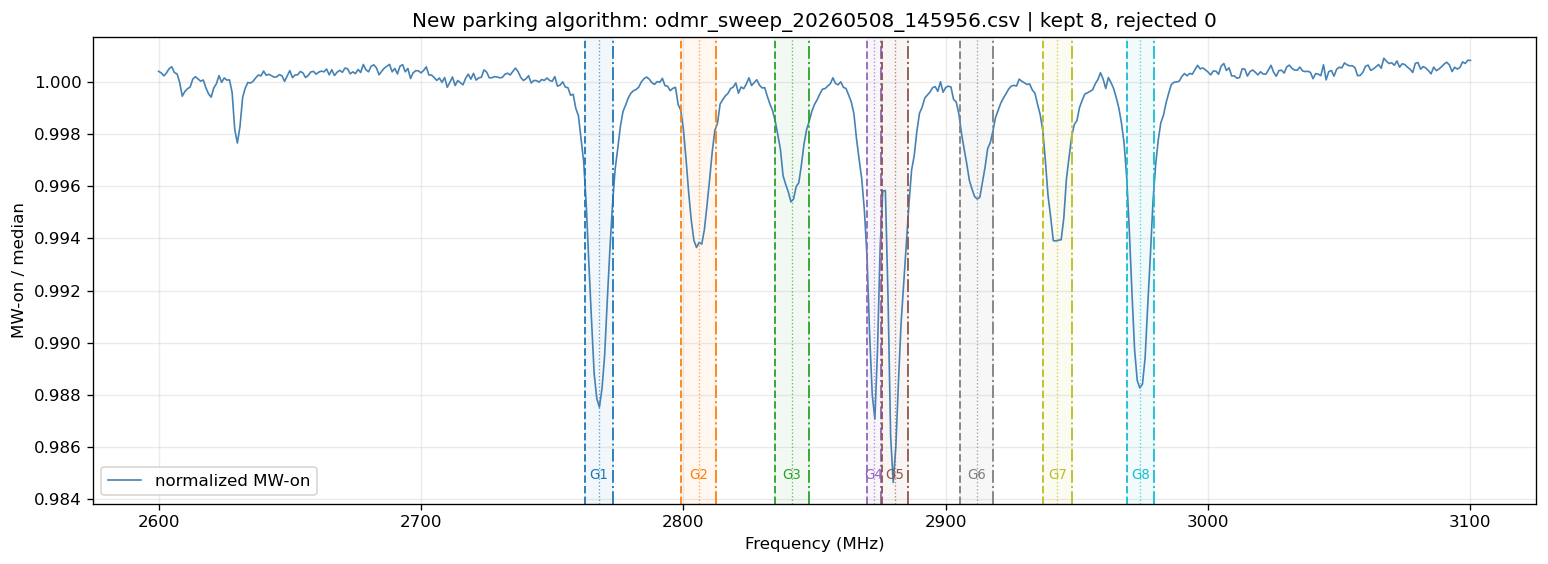

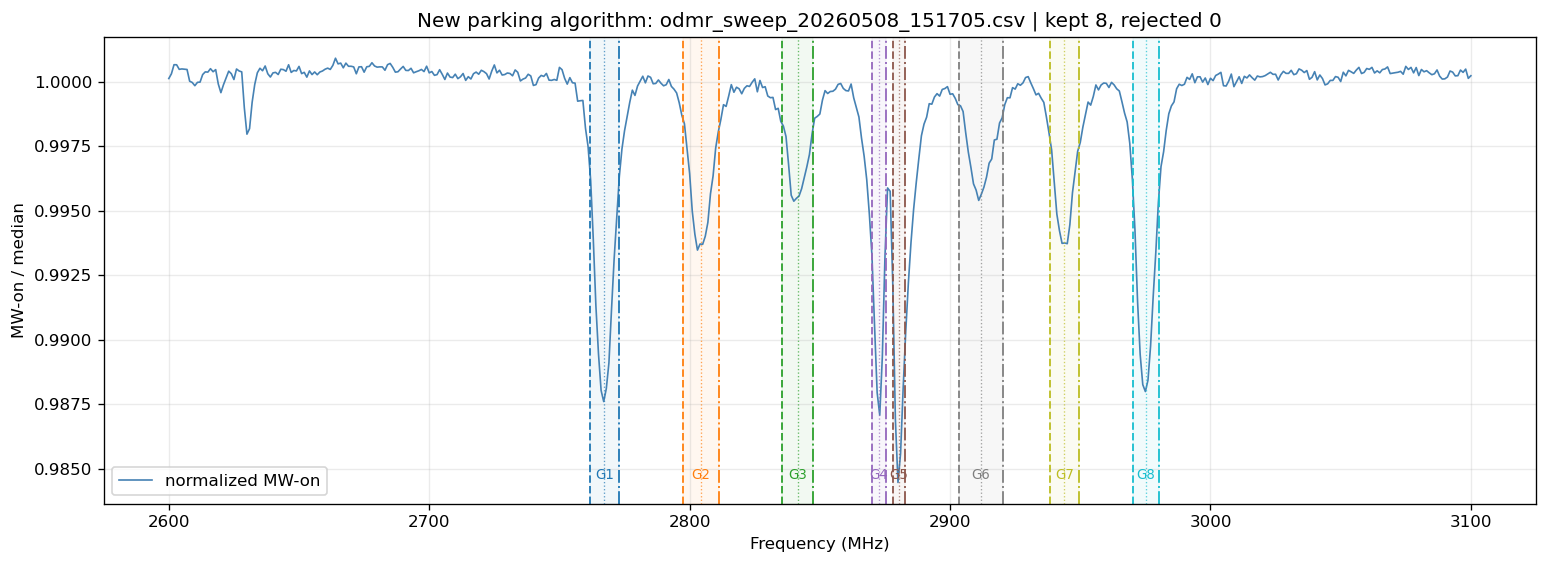

Saved plots:
 - /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests/odmr_sweep_20260508_143836_new_parking_algorithm.png
 - /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests/odmr_sweep_20260508_144028_new_parking_algorithm.png
 - /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests/odmr_sweep_20260508_144228_new_parking_algorithm.png
 - /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests/odmr_sweep_20260508_144843_new_parking_algorithm.png
 - /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parking_algorithm_tests/odmr_sweep_20260508_145956_new_parking_algorithm.png
 - /Users/ckasemtantikul/Documents/PhD/NV Compact Ma

In [8]:
plot_results = results[-PLOT_LAST_N:] if PLOT_LAST_N is not None else results
plot_paths = []
for result in plot_results:
    out = plot_parking_result(result, save=True)
    if out is not None:
        plot_paths.append(out)

print("Saved plots:")
for path in plot_paths:
    print(" -", path)

## Inspect one sweep in detail

Change `INSPECT_INDEX` to look at another selected sweep. `-1` means the most recent selected sweep.

odmr_sweep_20260508_151705.csv
Collapsed centers: [2766.967, 2804.34, 2840.78, 2872.371, 2880.797, 2911.89, 2943.598, 2975.032]
Kept centers:      [2767.2, 2804.4, 2841.47, 2872.578, 2880.453, 2911.78, 2943.916, 2975.132]
Rejected centers:  []


,odmr_file,nv_group,boundary,ref_peak_center_mhz,fwhm_mhz,parking_freq_mhz,fit_success,fit_cost,contrast
0,odmr_sweep_20260508_151705.csv,1,DB,2767.200,10.977,2761.711,True,0.000001,0.017130
1,odmr_sweep_20260508_151705.csv,1,IB,2767.200,10.977,2772.688,True,0.000001,0.017130
2,odmr_sweep_20260508_151705.csv,2,DB,2804.400,13.901,2797.450,True,0.000001,0.010016
3,odmr_sweep_20260508_151705.csv,2,IB,2804.400,13.901,2811.351,True,0.000001,0.010016
4,odmr_sweep_20260508_151705.csv,3,DB,2841.470,11.707,2835.617,True,0.000001,0.005751
5,odmr_sweep_20260508_151705.csv,3,IB,2841.470,11.707,2847.324,True,0.000001,0.005751
6,odmr_sweep_20260508_151705.csv,4,DB,2872.578,5.410,2869.873,True,0.000001,0.013432
7,odmr_sweep_20260508_151705.csv,4,IB,2872.578,5.410,2875.283,True,0.000001,0.013432
8,odmr_sweep_20260508_151705.csv,5,DB,2880.453,4.414,2878.246,True,0.000004,0.011483
9,odmr_sweep_20260508_151705.csv,5,IB,2880.453,4.414,2882.660,True,0.000004,0.011483


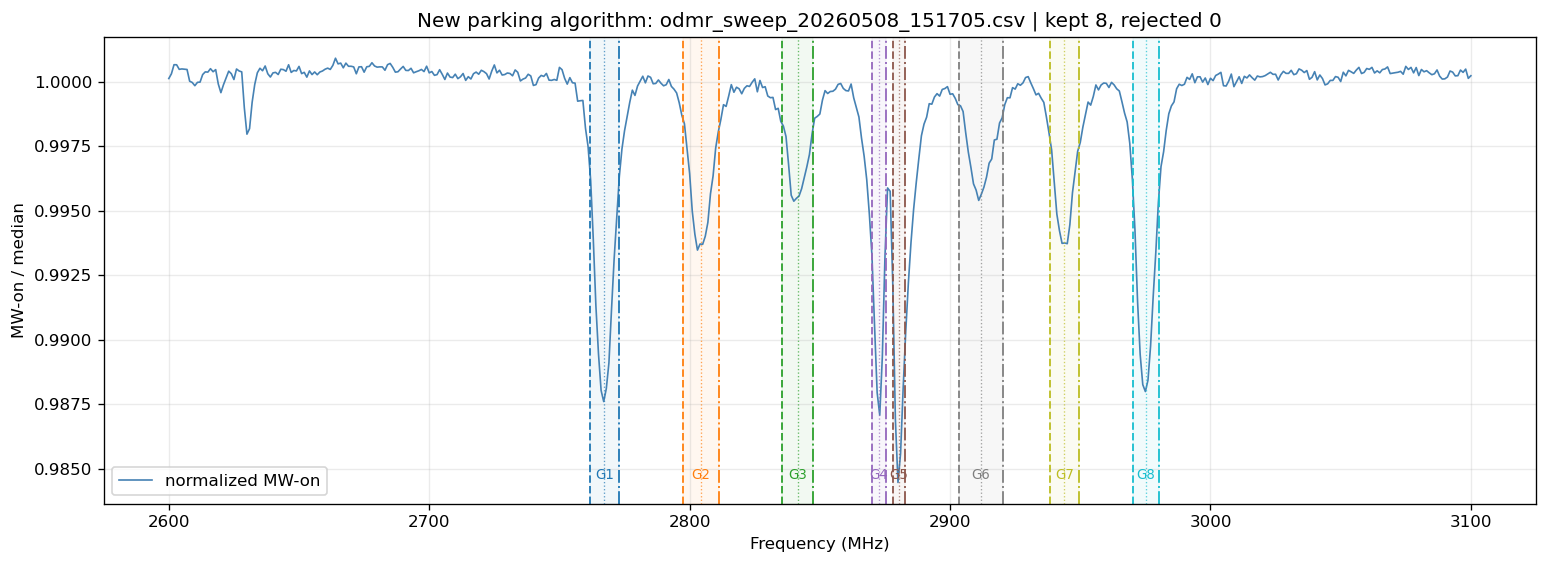

In [9]:
INSPECT_INDEX = -1
inspect_result = results[INSPECT_INDEX]

print(Path(inspect_result["path"]).name)
print("Collapsed centers:", np.round(inspect_result["centers"], 3).tolist())
print("Kept centers:     ", [round(f.center_mhz, 3) for f in inspect_result["kept"]])
print("Rejected centers: ", [round(f.center_mhz, 3) for f in inspect_result["rejected"]])

display(inspect_result["parking_df"].round({
    "ref_peak_center_mhz": 3,
    "fwhm_mhz": 3,
    "parking_freq_mhz": 3,
    "fit_cost": 6,
    "contrast": 6,
}))
_ = plot_parking_result(inspect_result, save=False)